# Data Exploration

In [1]:
!pip install seaborn
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install transformers[torch]==4.57.6
!pip install sentencepiece tqdm protobuf
!pip install accelerate

In [2]:
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import pipeline
from tqdm.auto import tqdm

In [3]:
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")

CUDA available: True
Device count: 1
Current device: 0
Device name: NVIDIA GB10


In [4]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("facebook/nllb-200-distilled-600M")
model = AutoModelForSeq2SeqLM.from_pretrained("facebook/nllb-200-distilled-600M")

def translate(text, src_lang, tgt_lang):
    tokenizer.src_lang = src_lang
    inputs = tokenizer(text, return_tensors="pt")
    target_lang_id = tokenizer.convert_tokens_to_ids(tgt_lang)
    outputs = model.generate(**inputs, forced_bos_token_id=target_lang_id)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

print(translate("le chat noir est rentré chez lui", src_lang="fra_Latn", tgt_lang="eng_Latn"))
print(translate("la plage est belle aujourd'hui", src_lang="fra_Latn", tgt_lang="eng_Latn"))
print(translate("je suis de Nice, mais j'habite ici maintenant", src_lang="fra_Latn", tgt_lang="eng_Latn"))

The black cat came home
The beach is beautiful today
I'm from Nice, but I live here now.


In [5]:
english_file = open("data/fr-en/europarl-v7.fr-en.en", encoding="utf-8").read().splitlines()
french_file = open("data/fr-en/europarl-v7.fr-en.fr", encoding="utf-8").read().splitlines()

In [6]:
pairs = list(zip(english_file, french_file))

clean_pairs = []

for en, fr in pairs:
    if len(en.split()) < 3 or len(fr.split()) < 3:
        continue
    if len(en) > 300 or len(fr) > 300:
        continue
    clean_pairs.append((en, fr))

print(clean_pairs[0])
print(clean_pairs[-1])
print(f'Originally, pairs had length {len(pairs)}')
print(f'After cleaning, pairs has length {len(clean_pairs)}')
print(f'{len(pairs) - len(clean_pairs)} pairs were removed. That is {round((len(pairs) - len(clean_pairs)) / len(pairs) * 100, 2)}% of the dataset.')

('Resumption of the session', 'Reprise de la session')
('(The sitting was closed at 10.50 a.m.)', '(La séance est levée à 10h50)')
Originally, pairs had length 2007723
After cleaning, pairs has length 1788430
219293 pairs were removed. That is 10.92% of the dataset.


In [7]:
clean_10k = clean_pairs[0:10000]

In [9]:
if not torch.cuda.is_available():
    print("WARNING: CUDA not found. This will be extremely slow on CPU.")
else:
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")

translator = pipeline(
    "translation_xx_to_yy", 
    model="facebook/nllb-200-distilled-600M",
    dtype=torch.float16, 
    device=0
)

def data_generator(data):
    for text in data:
        yield text

translations = []

for out in tqdm(
    translator(
        (pair[1] for pair in clean_10k), 
        src_lang="fra_Latn", 
        tgt_lang="eng_Latn", 
        batch_size=512,
        num_beams=2,              # better quality vs speed tradeoff
        length_penalty=1.0,
        do_sample=False,
        no_repeat_ngram_size=3,   # Stop repeats
        repetition_penalty=1.2,   # optional but helpful
        # truncation=True,
        # early_stopping=True,
        # use_cache=False,
    ), 
    total=len(clean_10k),
):
    translations.append(out[0]['translation_text'])

X = []
y = []
for i, (en, fr) in enumerate(clean_10k):
    X.append(en)
    y.append(0)
    X.append(translations[i])
    y.append(1)

X = np.array(X)
y = np.array(y)

print(f"Final Shape: {X.shape}, {y.shape}")

Using GPU: NVIDIA GB10


Device set to use cuda:0


  0%|          | 0/10000 [00:00<?, ?it/s]

Final Shape: (20000,), (20000,)


In [15]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM


class OptimizedNLLBTranslator:
    def __init__(
        self,
        model_name: str = "facebook/nllb-200-distilled-600M",
        max_length: int = 256,
        batch_size: int = 16,
        use_fp16: bool = True,
        compile_model: bool = False,
    ):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.max_length = max_length
        self.batch_size = batch_size

        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

        dtype = torch.float16 if (use_fp16 and self.device == "cuda") else torch.float32

        self.model = AutoModelForSeq2SeqLM.from_pretrained(
            model_name,
            torch_dtype=dtype,
            low_cpu_mem_usage=True
        ).to(self.device)

        if compile_model and hasattr(torch, "compile"):
            self.model = torch.compile(self.model)

        self.model.eval()

    @torch.inference_mode()
    def translate_batch(self, texts, src_lang: str, tgt_lang: str):
        """
        Translate a list of texts efficiently in batches.
        """
        self.tokenizer.src_lang = src_lang
        tgt_token_id = self.tokenizer.convert_tokens_to_ids(tgt_lang)

        results = []
        num_batches = (len(texts) + self.batch_size - 1) // self.batch_size

        for i in tqdm(range(0, len(texts), self.batch_size), total=num_batches, desc="Translating"):
            batch = texts[i : i + self.batch_size]

            inputs = self.tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=self.max_length,
            ).to(self.device)

            # Generate translation
            generated_tokens = self.model.generate(
                **inputs,
                forced_bos_token_id=tgt_token_id,
                max_length=self.max_length,
                num_beams=2,              
                length_penalty=1.0,
                do_sample=False,
                no_repeat_ngram_size=3,
                repetition_penalty=1.2,
                early_stopping=True,
            )

            decoded = self.tokenizer.batch_decode(
                generated_tokens,
                skip_special_tokens=True
            )

            results.extend(decoded)

        return results


translator = OptimizedNLLBTranslator(
    batch_size=512,
    use_fp16=True,
    compile_model=True
)

translations = translator.translate_batch(
    clean_10k[:500],
    src_lang="fra_Latn",
    tgt_lang="eng_Latn"
)

X = []
y = []
for i, (en, fr) in enumerate(clean_10k[:500]):
    X.append(en)
    y.append(0)
    X.append(translations[i])
    y.append(1)

X = np.array(X)
y = np.array(y)

print(f"Final Shape: {X.shape}, {y.shape}")

Translating: 100%|██████████| 1/1 [00:54<00:00, 54.30s/it]

Final Shape: (1000,), (1000,)


In [12]:
m = 7030
# m = 15
print(clean_10k[m])
print("---")
print(X[m*2])
print("---")
print(X[m*2+1])
print("---")
print(y[m*2])
print("---")
print(y[m*2+1])

for m in range(10, 20):
    print(clean_10k[m][1], X[m*2], X[m*2+1], sep="\t")

('President. I have received several proposed amendments relating to the topical and urgent subjects of major importance.', "La Présidente.- En ce qui concerne les problèmes d'actualité, urgents et d'importance majeure, j'ai plusieurs demandes de modification.")
---
President. I have received several proposed amendments relating to the topical and urgent subjects of major importance.
---
PRESIDENT. - With regard to current, urgent and major problems, I have several requests for amendments.
---
0
---
1
Oui, Monsieur Evans, je pense qu'une initiative dans le sens que vous venez de suggérer serait tout à fait appropriée.	Yes, Mr Evans, I feel an initiative of the type you have just suggested would be entirely appropriate.	Yes, Mr Evans, I think an initiative in the sense you just suggested would be quite appropriate.
Si l'Assemblée en est d'accord, je ferai comme M. Evans l'a suggéré.	If the House agrees, I shall do as Mr Evans has suggested.	If the House agrees, I will do as Mr Evans has

In [14]:
X = []
y = []

for en, fr in tqdm(clean_10k):
    X.append(en)
    y.append(0)
    
    X.append(translate(fr, src_lang="fra_Latn", tgt_lang="eng_Latn"))
    y.append(1)

X = np.array(X)
y = np.array(y)
print(X.shape)
print(y.shape)

  0%|          | 1/10000 [00:02<6:06:37,  2.20s/it]


KeyboardInterrupt: 

In [17]:
data = {
    "text": X,
    "label": y
}

df = pd.DataFrame(data)
# df.to_parquet("data/fr-en/fr-machine-translation-10k.parquet", compression="snappy", index=False)

print("File saved successfully!")

File saved successfully!


In [11]:
# df = pd.read_parquet('data/fr-en/fr-machine-translation-10k.parquet', engine='pyarrow')

In [18]:
punctuations = string.punctuation

def count_punct(text):
    counts = {}
    for char in text:
        if char in punctuations:
            counts[char] = counts.get(char, 0) + 1
    return counts

df['punct_counts'] = df['text'].apply(count_punct)
df.head()

,text,label,punct_counts
0,Resumption of the session,0,{}
1,Reprise of the session Reprise of the session,1,{}
2,I declare resumed the session of the European ...,0,"{',': 1, '.': 1}"
3,I declare resumed the session of the European ...,1,"{',': 1, '.': 1}"
4,"Although, as you will have seen, the dreaded '...",0,"{',': 3, ''': 2, '.': 1}"


## Are there punctuation patterns per label group?

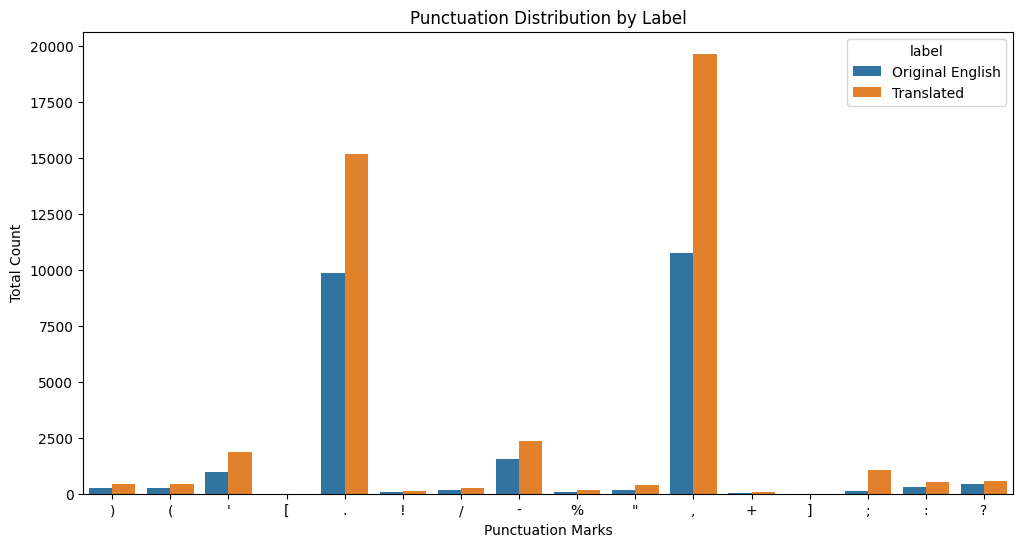

In [19]:
label_0_counts = {}
label_1_counts = {}

for idx, row in df.iterrows():
    if row['label'] == 0:
        for punct, count in row['punct_counts'].items():
            label_0_counts[punct] = label_0_counts.get(punct, 0) + count
    else:
        for punct, count in row['punct_counts'].items():
            label_1_counts[punct] = label_1_counts.get(punct, 0) + count

all_punct = set(label_0_counts.keys()) | set(label_1_counts.keys())

punct_df = pd.DataFrame({
    'punctuation': list(all_punct),
    'Original English': [label_0_counts.get(p, 0) for p in all_punct],
    'Translated': [label_1_counts.get(p, 0) for p in all_punct]
})

punct_df_melted = punct_df.melt(id_vars='punctuation', var_name='label', value_name='count')

colors = ["#1f77b4", "#ff7f0e"]

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=punct_df_melted, 
    x='punctuation', 
    y='count', 
    hue='label', 
    palette=colors
)

plt.title('Punctuation Distribution by Label')
plt.xlabel('Punctuation Marks')
plt.ylabel('Total Count')
plt.show()

In [20]:
# Compute various features
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df['punct_count'] = df['text'].apply(lambda x: sum(1 for c in x if c in string.punctuation))
df['unique_words'] = df['text'].apply(lambda x: len(set(x.lower().split())))
df['lexical_diversity'] = df['unique_words'] / df['word_count'].replace(0, 1)  # Avoid division by zero

# Display summary statistics by label
summary_stats = df.groupby('label')[['text_length', 'word_count', 'punct_count', 'unique_words', 'lexical_diversity']].describe()
scannable_stats = summary_stats.stack(level=0).swaplevel(0, 1).sort_index()
display(scannable_stats)

count        mean         std        min  \
                  label                                               
lexical_diversity 0      10000.0    0.909663    0.079244   0.560000   
                  1      10000.0    0.729770    0.166746   0.316667   
punct_count       0      10000.0    2.503800    1.678353   0.000000   
                  1      10000.0    4.306200    2.989872   0.000000   
text_length       0      10000.0  127.856500   63.587504  13.000000   
                  1      10000.0  208.029400  116.722324  17.000000   
unique_words      0      10000.0   19.165900    8.489769   3.000000   
                  1      10000.0   23.203300   10.441632   3.000000   
word_count        0      10000.0   21.693000   10.662050   3.000000   
                  1      10000.0   34.552000   18.851367   3.000000   

                                25%         50%         75%    max  
                  label                                             
lexical_diversity 0        0.857143    0.916667    1.000000    1.0  
                  1        0.590059    0.700000    0.878788    1.0  
punct_count       0        1.000000    2.000000    3.000000   20.0  
                  1        2.000000    4.000000    6.000000   39.0  
text_length       0       77.000000  120.000000  172.000000  300.0  
                  1      112.000000  194.000000  282.000000  590.0  
unique_words      0       13.000000   19.000000   25.000000   46.0  
                  1       15.000000   23.000000   31.000000   61.0  
word_count        0       13.000000   20.000000   29.000000   58.0  
                  1       19.000000   32.000000   47.000000   95.0

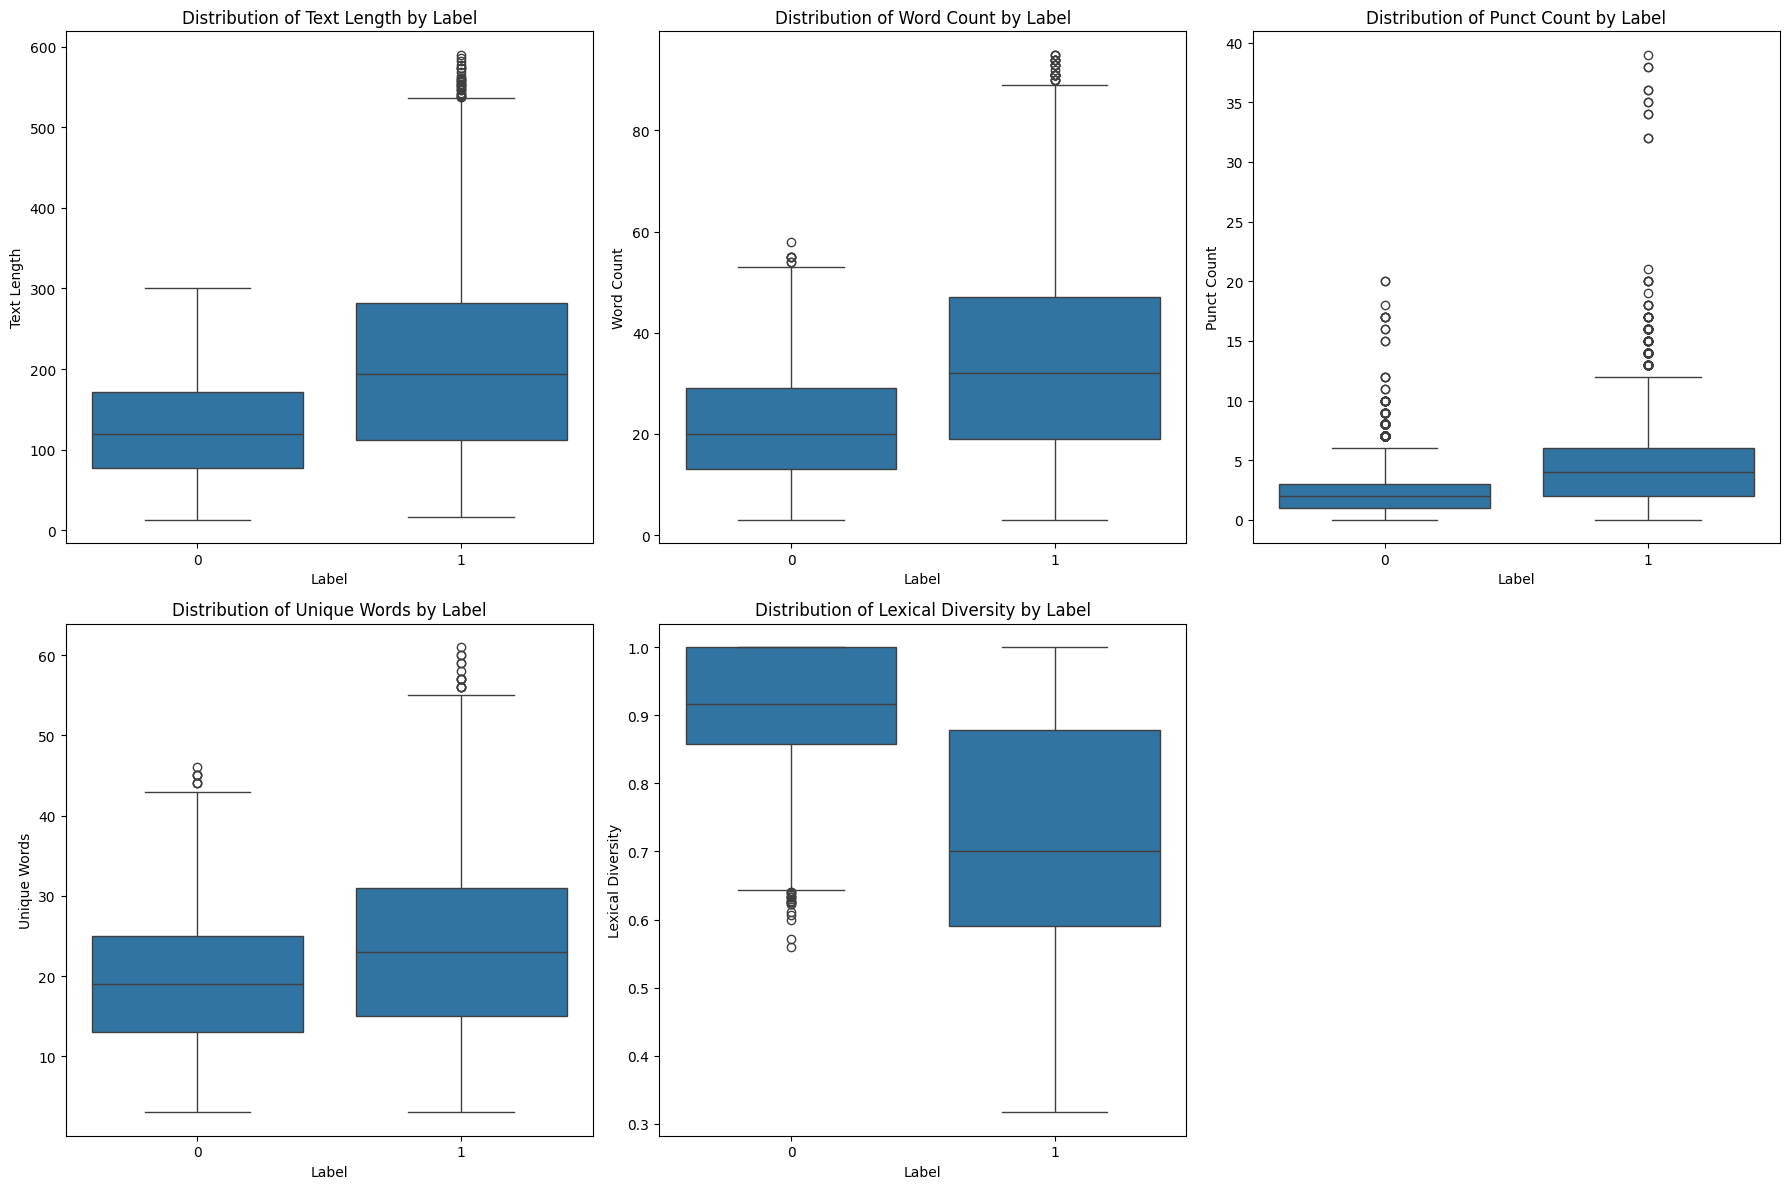

In [21]:
# Visualize distributions
features = ['text_length', 'word_count', 'punct_count', 'unique_words', 'lexical_diversity']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='label', y=feature, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature.replace("_", " ").title()} by Label')
    axes[i].set_xlabel('Label')
    axes[i].set_ylabel(feature.replace("_", " ").title())

if len(features) < len(axes):
    for j in range(len(features), len(axes)):
        axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [22]:
from scipy.stats import ttest_ind

# Perform t-tests for each feature
print("T-test results for differences between labels:")
for feature in features:
    group_0 = df[df['label'] == 0][feature]
    group_1 = df[df['label'] == 1][feature]
    t_stat, p_value = ttest_ind(group_0, group_1)
    print(f"{feature}: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}")
    if p_value < 0.05:
        print("  -> Significant difference (p < 0.05)")
    else:
        print("  -> No significant difference (p >= 0.05)")
    print()

T-test results for differences between labels:
text_length: t-statistic = -60.317, p-value = 0.000
  -> Significant difference (p < 0.05)

word_count: t-statistic = -59.374, p-value = 0.000
  -> Significant difference (p < 0.05)

punct_count: t-statistic = -52.568, p-value = 0.000
  -> Significant difference (p < 0.05)

unique_words: t-statistic = -30.001, p-value = 0.000
  -> Significant difference (p < 0.05)

lexical_diversity: t-statistic = 97.441, p-value = 0.000
  -> Significant difference (p < 0.05)



In [23]:
translated_df = df[df['label'] == 1].reset_index(drop=True)
original_df = df[df['label'] == 0].reset_index(drop=True)

longest_idx = translated_df['text_length'].idxmax()
print(f"Longest string is at position: {longest_idx}")

longest_translated = translated_df.loc[longest_idx, 'text']
original_english = original_df.loc[longest_idx, 'text']

print(longest_translated)
print("---")
print(original_english)

Longest string is at position: 4903
Mr. President, Commissioner, regarding the relationship between science, on the one hand, and the application of the precautionary principle, on the other, the communication states that invoking that precautionary principle always requires a political decision if there is a lack of scientific evidence.Mr. President, Madam Commissioner, on the problem of the relationship between science and recourse to the precautionary principle, the communication establishes that recourse to the precautionary principle always requires a political decision when there is a lack of scientific evidence.
---
Mr President, Commissioner, regarding the relationship between science, on the one hand, and applying the precautionary principle on the other, the communication states that invoking that precautionary principle always requires a political decision if there is a lack of scientific evidence.


In [52]:
test = "La Présidente.- En ce qui concerne les problèmes d'actualité, urgents et d'importance majeure, j'ai plusieurs demandes de modification."
print(translate(test, src_lang="fra_Latn", tgt_lang="eng_Latn"))

President. - As regards the current, urgent and major problems, I have several requests for amendments.


In [19]:
print(clean_pairs[7030])

('President. I have received several proposed amendments relating to the topical and urgent subjects of major importance.', "La Présidente.- En ce qui concerne les problèmes d'actualité, urgents et d'importance majeure, j'ai plusieurs demandes de modification.")


In [20]:
print(df['text'].str.len().idxmax())
print(df.loc[14061])

9265
text                 President. - As regards the current, urgent an...
label                                                                1
punct_counts                                  {'.': 2, '-': 1, ',': 2}
text_length                                                        103
word_count                                                          16
punct_count                                                          5
unique_words                                                        16
lexical_diversity                                                  1.0
Name: 14061, dtype: object
